In [14]:
# --- Бібліотеки для даної роботи ---
try:
    import pandas, matplotlib, jinja2
    print("Бібліотеки вже встановлені. Пропускаємо інсталяцію.")
except ImportError:
    print("Встановлюємо бібліотеки...")
    %pip install pandas matplotlib jinja2

Бібліотеки вже встановлені. Пропускаємо інсталяцію.


## Задача 3. Формування "Команди мрії"

**Умова:**

Ви — Tech Lead нового амбітного стартапу. Ваше перше завдання — сформувати ідеальну команду для розробки MVP (Minimum Viable Product). HR-відділ надав вам списки кандидатів, які успішно пройшли технічну співбесіду.

У пулі кандидатів є:
* Back-end розробники: 8 осіб
* Front-end розробники: 6 осіб
* UI/UX Дизайнери: 4 особи

Згідно з бюджетом та архітектурою проєкту, команда має складатися рівно з **5 осіб** і мати таку структуру:
1.  **2** Back-end розробники.
2.  **2** Front-end розробники.
3.  **1** Дизайнер.

Оскільки всі кандидати у списках кваліфіковані, порядок їх вибору не має значення (команда "Олег і Анна" — це те саме, що "Анна і Олег").

Тобто, це задача на **сполучення** (combinations). Однак, оскільки ми формуємо одну цілісну команду з різних груп, нам знадобиться **правило множення**.

**Напишіть програму на Python, яка використовує модуль `math` та виконує наступні кроки:**

1.  Обчисліть, скількома способами можна вибрати необхідну кількість Back-end розробників.
2.  Обчисліть, скількома способами можна вибрати необхідну кількість Front-end розробників.
3.  Обчисліть, скількома способами можна вибрати одного дизайнера.
4.  Використовуючи комбінаторне правило множення, знайдіть **загальну кількість** можливих унікальних складів команди.
5.  Виведіть проміжні результати та фінальну відповідь у зрозумілому форматі.

Красивий Вивід (Аналітичний звіт):


,Роль,Всього кандидатів,Потрібно в команду,Варіантів вибору
0,Back-end,8,2,28
1,Front-end,6,2,15
2,Design,4,1,4
Total,РАЗОМ (Множення),-,5,1680


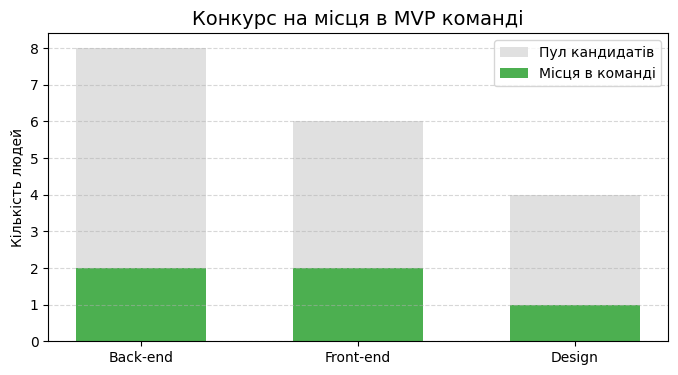


🏆 ФІНАЛЬНИЙ РЕЗУЛЬТАТ: 1680 можливих унікальних складів команди.


Технічний вивід (Raw Data):
{'Back-end': 28, 'Front-end': 15, 'Design': 4, 'TOTAL_TEAMS': 1680}


In [15]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

roles = {
    "Back-end": {"total": 8, "needed": 2},
    "Front-end": {"total": 6, "needed": 2},
    "Design":   {"total": 4, "needed": 1}
}

results = []
total_combinations = 1

for role, data in roles.items():
    ways = math.comb(data["total"], data["needed"])

    total_combinations *= ways

    results.append({
        "Роль": role,
        "Всього кандидатів": data["total"],
        "Потрібно в команду": data["needed"],
        "Варіантів вибору": ways
    })

print("Красивий Вивід (Аналітичний звіт):")
df = pd.DataFrame(results)
df.loc['Total'] = ['РАЗОМ (Множення)', '-', 5, total_combinations]

styled_df = df.style.background_gradient(subset=['Варіантів вибору'], cmap='Blues')
display(styled_df)

names = [r["Роль"] for r in results]
total_vals = [r["Всього кандидатів"] for r in results]
needed_vals = [r["Потрібно в команду"] for r in results]

plt.figure(figsize=(8, 4))
plt.bar(names, total_vals, color='#e0e0e0', label='Пул кандидатів', width=0.6)
plt.bar(names, needed_vals, color='#4CAF50', label='Місця в команді', width=0.6)

plt.title("Конкурс на місця в MVP команді", fontsize=14)
plt.ylabel("Кількість людей")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(f"\n🏆 ФІНАЛЬНИЙ РЕЗУЛЬТАТ: {total_combinations} можливих унікальних складів команди.\n")
print("="*60)

print("\nТехнічний вивід (Raw Data):")
technical_data = {row["Роль"]: row["Варіантів вибору"] for row in results}
technical_data["TOTAL_TEAMS"] = total_combinations
print(technical_data)

### **Аналітичні обчислення**

Використовуємо формулу **сполучень** (combinations), оскільки порядок вибору кандидатів всередині однієї групи не має значення:
$$C_n^k = \frac{n!}{k!(n-k)!}$$

Де:
* $n$ — загальна кількість кандидатів у групі.
* $k$ — кількість, яку потрібно обрати.
* $!$ — факторіал числа.

#### Крок 1: Back-end розробники
Обираємо 2 з 8:
$$C_8^2 = \frac{8!}{2!(8-2)!} = \frac{8!}{2! \cdot 6!} = \frac{7 \cdot 8}{1 \cdot 2} = \frac{56}{2} = 28$$

#### Крок 2: Front-end розробники
Обираємо 2 з 6:
$$C_6^2 = \frac{6!}{2!(6-2)!} = \frac{6!}{2! \cdot 4!} = \frac{5 \cdot 6}{1 \cdot 2} = \frac{30}{2} = 15$$

#### Крок 3: Дизайнери
Обираємо 1 з 4:
$$C_4^1 = \frac{4!}{1!(4-1)!} = \frac{4!}{1! \cdot 3!} = 4$$

#### Крок 4: Загальний результат (Правило множення)
Оскільки вибір кожної групи є незалежною подією, для формування цілісної команди перемножуємо варіанти:

$$Total = C_8^2 \times C_6^2 \times C_4^1$$
$$Total = 28 \times 15 \times 4$$
$$Total = 420 \times 4 = 1680$$

**Відповідь:** Tech Lead має **1680** способів сформувати команду.